In [3]:
import numpy as np
from sklearn.metrics import accuracy_score
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [4]:
from keras.datasets import mnist
(x_train, y_train),(x_test, y_test) = mnist.load_data()

# Understanding MNIST Data Loading (Keras)

## Key Idea

In the MNIST dataset, **features (images)** and **labels (targets)** are already separated for you.

---

## Code

```python
from keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
```

---

## What does this return?

The function returns a **nested tuple**:

```python
((train_images, train_labels), (test_images, test_labels))
```

---

##  How Python assigns values

Python assigns variables **by position**, not by meaning:

```python
(x_train, y_train), (x_test, y_test) = ...
```

This means:

* `x_train` ← train images
* `y_train` ← train labels
* `x_test` ← test images
* `y_test` ← test labels

---

## Important Clarification

* Keras does **NOT** know your variable names
* Python does **NOT** understand "features" or "labels"
* Assignment is purely based on **order**

---

## Proof

This works exactly the same:

```python
(a, b), (c, d) = mnist.load_data()
```

But now:

* `a` = images
* `b` = labels

Names don’t matter — **position does**

---

## Why this structure?

Keras is designed to return:

```python
(train_X, train_y), (test_X, test_y)
```

So we follow the same convention for clarity.

---

## Standard ML Convention

* `X` → features (inputs, images)
* `y` → labels (targets, outputs)

So:

```python
(x_train, y_train)
```

is just a **naming convention**, not a requirement.

---

## Mental Model

```
Dataset
│
├── Train
│     ├── X (images)
│     └── y (labels)
│
└── Test
      ├── X (images)
      └── y (labels)
```

---

## Final Takeaways

* MNIST already provides **separated features and labels**
* Python assigns values based on **position, not meaning**
* Variable names are for **readability only**
* Follow `(X, y)` convention to avoid confusion

---

## Common Mistake

Swapping order like this:

```python
(y_train, x_train), (y_test, x_test) = mnist.load_data()
```

This will silently break your pipeline

---

## Engineer Insight

Always think:

> "What does this function return structurally?"

Not:

> "What do I want the variables to mean?"

---


In [5]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.2, random_state = 42)

#  Why Do We Split MNIST Again? (Train vs Validation vs Test)

##  Initial Dataset (from Keras)

```python
from keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
```

This gives you:

* **Training set** → used for learning
* **Test set** → used for final evaluation

---

## The Problem

If you only have **train + test**, then:

* How do you tune hyperparameters?
* How do you monitor training performance?
* How do you choose the best model?

 If you use the **test set** for this → ❌ **data leakage**

---

##  Solution: Create a Validation Set

We split the training data:

```python
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)
```

---

## After Splitting

| Dataset    | Size   | Purpose                          |
| ---------- | ------ | -------------------------------- |
| Train      | 48,000 | Learn model weights              |
| Validation | 12,000 | Tune model & monitor performance |
| Test       | 10,000 | Final unbiased evaluation        |

---

## Dataset Flow

```
Original MNIST
│
├── Train (60,000)
│     └── Split → Train (48k) + Validation (12k)
│
└── Test (10,000)
```

---

## Roles of Each Set

### Train Set

* Used to **train the model**
* Model updates weights here

---

### Validation Set

* Used during training
* Helps:

  * Tune hyperparameters
  * Detect overfitting
  * Select best model

---

### Test Set

* Used **only once at the end**
* Gives final performance

---

## Common Mistakes

### Using test data during training

* Leads to **data leakage**
* Results become overly optimistic

---

### Skipping validation

* No way to properly tune model
* High risk of overfitting

---

## Key Insight

> **Train → Learn**
> **Validation → Tune**
> **Test → Final Check**

---

## Important Rule

Never use the **test set** until:

* Training is complete
* All decisions are finalized

---

## Final Takeaway

* MNIST provides **train + test**
* You must create **validation from training**
* Each dataset has a **distinct role**

---

## Engineer Mindset

Always ask:

> “Am I using the test set too early?”

If yes → your evaluation is invalid.

---


In [6]:
print("x_train [shape %s] sample patch: \n" % str(x_train.shape), x_train[1, 15:20, 5:10])

x_train [shape (48000, 28, 28)] sample patch: 
 [[  0  77 254 154   0]
 [  0 145 253  96   0]
 [  0 254 238  37   0]
 [  0 254 229   0   0]
 [  0 254 246  69   0]]


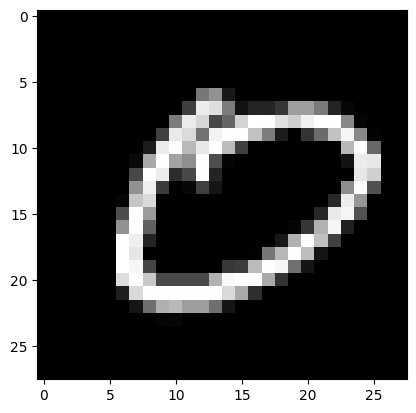

In [7]:
import matplotlib.pyplot as plt

plt.imshow(x_train[1] , cmap='gray')
plt.show()

In [8]:
x_train.shape[0]

48000

In [9]:
from keras.datasets import mnist
(x_train, y_train),(x_test, y_test) = mnist.load_data()

#preprocessing data - scale the pixel values to the range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

#reshape the data to fit the model input
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

#one-hot encode the labels
y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes = 10)
y_test_one_hot = tf.keras.utils.to_categorical(y_test, num_classes = 10)

#create some of hidden layers and the output layer
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)), # to flatten the 28x28 images into a 1D vector of size 784
    tf.keras.layers.Dense(500, activation='sigmoid'),
    tf.keras.layers.Dense(100, activation='sigmoid'),
    tf.keras.layers.Dense(10, activation='softmax'),  
])

model.summary()

c:\Users\Lenovo\Desktop\DEPI(R_2)\ML_git\GIZ4_AIS2_S1_Ml\.env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        50,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 443,610 (1.69 MB)

 Trainable params: 443,610 (1.69 MB)

 Non-trainable params: 0 (0.00 B)

**Quick Note: Scaling vs Activation**

* Dividing by 255 scales inputs to **[0, 1]**
* **Sigmoid** outputs in **(0, 1)** → matches this range
* **Tanh** outputs in **(-1, 1)** → needs scaling like:

  ```python
  x = (x / 127.5) - 1
  ```
* Using tanh with [0,1] inputs works but is not optimal
* In practice, **ReLU is usually better than both** for hidden layers


# Understanding Scaling and Activation Functions in MNIST

## 1) Input Scaling

In the code:

```python
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0
```

This converts pixel values from the range:

```
[0, 255] → [0, 1]
```

### Why this is important

* Neural networks train more efficiently with smaller, normalized inputs
* Improves numerical stability
* Speeds up convergence

Note: This is normalization to `[0,1]`, not full MinMax scaling across features.

---

## 2) Sigmoid Activation

Sigmoid function:

[
\sigma(x) = \frac{1}{1 + e^{-x}}
]

* Output range: `(0, 1)`

### Why it works with this scaling

* Input values are in `[0,1]`
* Output of sigmoid is also in `(0,1)`
* This creates consistent value ranges across layers

### Limitation

* Suffers from vanishing gradients
* Slower training in deeper networks
* Not commonly used in hidden layers today

---

## 3) Tanh Activation

Tanh function:

[
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
]

* Output range: `(-1, 1)`
* Zero-centered (advantage over sigmoid)

---

## 4) Correct Scaling for Tanh

If using `tanh`, inputs should be scaled to `[-1, 1]`:

```python
x_train = (x_train / 127.5) - 1
x_test  = (x_test  / 127.5) - 1
```

### Why

* Matches activation output range
* Improves convergence
* Keeps data centered around zero

---

## 5) What if you don’t adjust scaling?

Using:

* `tanh` with `[0,1]` input

Leads to:

* Non-centered inputs
* Slower learning
* Suboptimal performance

---

## 6) Recommended Practice

Instead of sigmoid or tanh in hidden layers, use:

```python
activation = 'relu'
```

### Why ReLU

* Avoids vanishing gradient problem
* Faster convergence
* Standard choice in modern deep learning

---

## 7) Summary

| Activation | Output Range | Recommended Input      |
| ---------- | ------------ | ---------------------- |
| Sigmoid    | (0, 1)       | [0, 1]                 |
| Tanh       | (-1, 1)      | [-1, 1]                |
| ReLU       | [0, ∞)       | [0, 1] or standardized |

---

## 8) Practical Recommendation for MNIST

```python
x_train = x_train / 255.0
x_test  = x_test / 255.0
```

```python
activation = 'relu'
```

---

## Final Takeaway

* Input scaling and activation functions must be aligned
* Sigmoid works with `[0,1]` but is outdated for hidden layers
* Tanh requires `[-1,1]` scaling
* ReLU is the preferred default in most cases


**Quick Note: Channels & Reshaping in MNIST**

* **Channel** = number of values per pixel

  * Grayscale → `1 channel`
  * RGB → `3 channels`

---

### Common Reshape Options

**1) For Dense (MLP) — Flatten**

```python
x_train = x_train.reshape(-1, 784)
```

* Shape → `(N, 784)`
* Loses spatial structure
* Used with `Dense` layers

---

**2) For CNN — Keep image structure**

```python
x_train = x_train.reshape(-1, 28, 28, 1)
```

* Shape → `(N, 28, 28, 1)`
* Keeps spatial relationships
* Required for `Conv2D`

---

**3) Alternative reshape (explicit)**

```python
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
```

* Same as using `-1`
* More explicit, less flexible

---

### Key Idea

* Use `(784,)` → for **Dense networks**
* Use `(28,28,1)` → for **CNNs**

Reshape defines how the model interprets the data.


**Difference Between `(784,)` and `(28, 28, 1)`**

### 1) `(784,)` — Flattened Input

```python
x_train = x_train.reshape(-1, 784)
```

* Converts image into a **1D vector**
* Used with **Dense (MLP)** layers
* **Loses spatial structure** (no idea of pixel positions)
* Model sees data as just numbers

Final structure

x_train.shape = (60000, 784)

60000 → number of images

784 → features per image

So:

Each row = one image

Each column = one pixel value

---

### 2) `(28, 28, 1)` — Image Format

```python
x_train = x_train.reshape(-1, 28, 28, 1)
```

* Keeps **2D structure + channel**
* Used with **CNN (Conv2D)** layers
* **Preserves spatial relationships**
* Model can learn patterns (edges, shapes)

---

### Key Difference

| Shape       | Model Type | Spatial Info |
| ----------- | ---------- | ------------ |
| `(784,)`    | Dense      | Lost         |
| `(28,28,1)` | CNN        | Preserved    |

---

### Takeaway

* `(784,)` → treat image as a **flat vector**
* `(28,28,1)` → treat image as an **actual image**

The choice depends on the **model architecture**, not preference.


In [10]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train_one_hot, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8655 - loss: 0.5013 - val_accuracy: 0.9329 - val_loss: 0.2338
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9385 - loss: 0.2079 - val_accuracy: 0.9524 - val_loss: 0.1676
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9553 - loss: 0.1494 - val_accuracy: 0.9587 - val_loss: 0.1401
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9666 - loss: 0.1130 - val_accuracy: 0.9686 - val_loss: 0.1132
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9749 - loss: 0.0854 - val_accuracy: 0.9720 - val_loss: 0.0973
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9806 - loss: 0.0670 - val_accuracy: 0.9728 - val_loss: 0.0926
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9844 - loss: 0.0523 - val_accuracy: 0.9709 - val_loss: 0.0933
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9886 - loss: 0.0400 - val_accuracy

**Mini-batch size:** 64 points

**Number of mini-batches per epoch:** 750

**Total training samples:** 48,000

#  Training Process Explanation (Epochs & Mini-Batches)

##  Key Concepts

- **Epoch**: One full pass over the entire training dataset  
- **Mini-batch**: A subset of the dataset used to update the model once  
- **Batch size**: Number of samples in each mini-batch  

---

##  Our Case

- Batch size = **64**
- Number of mini-batches per epoch = **750**
- Total training samples = **48,000**

---

##  How Training Works

In each epoch:

- The dataset (48,000 samples) is divided into **750 mini-batches**
- Each mini-batch contains **64 samples**
- The model updates its weights **after every mini-batch**


the dropout is help me to reduce overfit and reactivate nodes that isn't working so make it to work

# How Training Actually Happens (Epoch → Batches → Updates)

## Setup

* Training samples ≈ **48,000** (after validation split)
* Batch size = **64**
* Number of batches per epoch:

```text
48000 ÷ 64 ≈ 750 batches
```

---

# 🧠 One Epoch = 750 Mini-Batches

## 🔁 Epoch 1 starts

### ➤ Batch 1 (samples 1 → 64)

```text
Step 1: Feedforward
- Pass 64 images through the network
- Get predictions (ŷ)

Step 2: Compute loss
- Compare ŷ with true labels (y)
- Get error value

Step 3: Backpropagation
- Compute gradients (how wrong each weight is)

Step 4: Update weights
- Optimizer (Adam) adjusts weights
```

👉 Model is now slightly better than before

---

### ➤ Batch 2 (samples 65 → 128)

Repeat same steps:

```text
Forward → Loss → Backward → Update
```

👉 Model improves again

---

### ➤ Batch 3 … Batch 750

This repeats:

```text
750 times per epoch
```

Each batch:

* sees different data
* updates weights slightly

---

# 📊 End of Epoch 1

After all 750 batches:

```text
Model has seen ALL training data once
```

Now compute:

* Training accuracy
* Training loss

---

## 🔍 Validation step

Then:

```text
Run ONLY feedforward on validation set
```

* No backprop
* No weight updates

👉 This gives:

```text
val_accuracy, val_loss
```

---

# 🔁 Epoch 2 starts

Same process again:

```text
750 batches → 750 updates
```

But now:

* weights are already better
* loss decreases faster

---

# 🔄 Full Training Loop

```text
For each epoch:
    For each batch:
        1. Forward pass
        2. Compute loss
        3. Backprop
        4. Update weights
    
    Evaluate on validation set
```

---

# 🧠 Key Insight

* **1 batch = 1 weight update**
* **1 epoch = ~750 updates**
* **10 epochs = ~7500 updates**

---

# ⚠️ Important Understanding

* Feedforward + backprop happens **inside each batch**
* NOT once per epoch
* Epoch is just a **full pass over data**

---

# 🧩 Mental Model

```text
Epoch
 ├── Batch 1 → update
 ├── Batch 2 → update
 ├── Batch 3 → update
 ...
 └── Batch 750 → update

Then:
→ Validation (no learning)
```

---

# 🧠 Final Takeaway

Training is not:

> “learn once per epoch”

Training is:

> “learn 750 times per epoch, small step each time”


In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test_one_hot)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9781 - loss: 0.0749
Test accuracy: 0.9781000018119812


In [12]:
def get_random_indices(total_images, num_images):
    return np.random.choice(total_images, num_images, replace=False)

#make predictions
predictions = model.predict(x_test)

x_test_images = x_test.reshape(-1,28,28,1)

prediction_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test_one_hot, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step


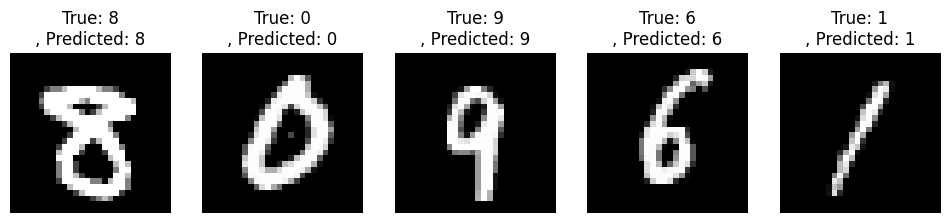

In [13]:
num_images = 5
random_indices = get_random_indices(len(x_test_images) , num_images)


def plot_images(images , labels , predictions):
    plt.figure(figsize=(12,8))
    for i in range(len(images)):
        plt.subplot(1 , len(images) , i+1)
        plt.imshow(images[i] , cmap='grey')
        plt.title(f"True: {labels[i]}\n, Predicted: {predictions[i]}")
        plt.axis('off')
    plt.show()

plot_images(x_test_images[random_indices] , true_classes[random_indices] , prediction_classes[random_indices])

In [14]:
from keras.datasets import mnist
from keras.callbacks import TensorBoard

NAME = 'mnist-28-28-v1'
tensorBoard = TensorBoard(log_dir='logs/{}'.format(NAME))

(x_train, y_train), (x_test, y_test) = mnist.load_data()
#preprocessing data - scale the data
x_train = x_train.astype('float32') /255.0
x_test = x_test.astype('float32') /255.0
#reshape data
x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)
#one hot encoding
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)
model = tf.keras.Sequential([
    #creatae some of hidden layers
    tf.keras.layers.Dense(500, activation='sigmoid', input_shape=(784,)),
    tf.keras.layers.Dense(100, activation='sigmoid'),
    tf.keras.layers.Dense(10, activation='softmax')                        
])


model.compile(optimizer= 'Adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train_oh, epochs=10, batch_size=64, validation_split=0.2, callbacks=[tensorBoard])


test_loss, test_acc = model.evaluate(x_test, y_test_oh)
print('Test accuracy:', test_acc)
#

c:\Users\Lenovo\Desktop\DEPI(R_2)\ML_git\GIZ4_AIS2_S1_Ml\.env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8671 - loss: 0.4971 - val_accuracy: 0.9283 - val_loss: 0.2477
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9380 - loss: 0.2101 - val_accuracy: 0.9510 - val_loss: 0.1686
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9550 - loss: 0.1501 - val_accuracy: 0.9578 - val_loss: 0.1427
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9666 - loss: 0.1107 - val_accuracy: 0.9662 - val_loss: 0.1151
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9740 - loss: 0.0852 - val_accuracy: 0.9702 - val_loss: 0.1001
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9797 - loss: 0.0674 - val_accuracy: 0.9722 - val_loss: 0.0904
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9850 - loss: 0.0515 - val_accuracy: 0.9732 - val_loss: 0.0872
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9888 - loss: 0.0393 - val_accuracy:

In [ ]:
# tensorboard --logdir=logs (to run in terminal)

In [20]:
from keras.datasets import mnist
from keras.callbacks import TensorBoard

list_activity = ['sigmoid', 'relu', 'tanh']
list_optimizer = ['Adam', 'SGD', 'RMSprop']
list_loss = ['categorical_crossentropy', 'mean_squared_error']

(x_train, y_train), (x_test, y_test) = mnist.load_data()
#preprocessing data - scale the data
x_train = x_train.astype('float32') /255.0
x_test = x_test.astype('float32') /255.0
#reshape data
x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)
#one hot encoding
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)

i = 1
accuracy_scores = []
for activity in list_activity:
    for optimizer in list_optimizer:
            NAME = f'mnist-28-28-{i}'
            tensorboard = TensorBoard(log_dir='./logs/{}'.format(NAME))


            model = tf.keras.Sequential([
                #creatae some of hidden layers
                tf.keras.layers.Dense(500, activation = activity, input_shape=(784,)),
                tf.keras.layers.Dense(100, activation = activity),
                tf.keras.layers.Dense(10, activation='softmax')                        
            ])
            model.compile(optimizer= optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
            history = model.fit(x_train, y_train_oh, epochs=10, batch_size=64, validation_split=0.2, callbacks=[tensorboard])
            test_loss, test_acc = model.evaluate(x_test, y_test_oh)
            print('Test accuracy:', test_acc)

            i += 1

c:\Users\Lenovo\Desktop\DEPI(R_2)\ML_git\GIZ4_AIS2_S1_Ml\.env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8692 - loss: 0.4954 - val_accuracy: 0.9306 - val_loss: 0.2326
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9377 - loss: 0.2090 - val_accuracy: 0.9494 - val_loss: 0.1721
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9558 - loss: 0.1495 - val_accuracy: 0.9615 - val_loss: 0.1344
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9672 - loss: 0.1106 - val_accuracy: 0.9643 - val_loss: 0.1216
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9751 - loss: 0.0855 - val_accuracy: 0.9701 - val_loss: 0.0996
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9809 - loss: 0.0661 - val_accuracy: 0.9728 - val_loss: 0.0921
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9852 - loss: 0.0511 - val_accuracy: 0.9735 - val_loss: 0.0872
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9888 - loss: 0.0396 - val_accur

# Batch Normalization (BatchNorm)

## What it does

BatchNorm normalizes the outputs (activations) of a layer for each mini-batch:

```
x_hat = (x - mean) / sqrt(variance + epsilon)
y = gamma * x_hat + beta
```

* `mean`, `variance`: computed from the current batch
* `gamma`, `beta`: learnable parameters

---

## Why we use it

* Stabilizes training (keeps values in a good range, Prevents exploding / vanishing values)
* Speeds up convergence
* Allows higher learning rates
* Adds slight regularization

---

## Where to place it

### Dense networks

```python id="m0c6t6"
Dense(...)
BatchNormalization()
Activation('relu')
```

### CNNs

```python id="wl6w5p"
Conv2D(...)
BatchNormalization()
Activation('relu')
```

Rule: use BatchNorm **before activation**

---

## When to use it

Use when:

* Model is deep
* Training is unstable
* Learning is slow

Avoid when:

* Batch size is very small
* Model is simple

---

## Example

```python id="5u9mti"
model = Sequential([
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dense(10, activation='softmax')
])
```

---

## Takeaway

BatchNorm keeps layer outputs well-scaled, making training faster and more stable.
